# Theoretical Copper profiles analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal


In [ ]:
#grid parameters
Npts = 2401
pz_min = -12.5
pz_max = 12.5

# physical parameters
n_gauss = 5
fourier_order = 5
spin_asymm = 0.8

# experimental parameters
t_count = 5e5
res_fwhm = 0.35
err_scaling = 1

# random parameters
gauss_width_range = (0.3, 2.0)
gauss_amp_range = (0.05, 1.0)
parab_curv_range = (-2.5, -1.5)
parab_offset_range = (1.5, 2.5)

fermi_window_width = 2
fermi_window_amp = 0.5
fermi_scale_range = (0.1, 0.2)
fermi_coeff_range = 0.3

n_train = 200000
n_test = 50000

pz = np.linspace(pz_min, pz_max, Npts)
grid_spacing = np.abs(pz[1] - pz[0])
res_sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing

rng = np.random.default_rng()

In [ ]:
def gaussian(x, width, amp):
    return (np.abs(amp) * np.exp(-0.5 * (x /(np.abs(width))) ** 2))


def parabola(x, vertex, curve, offset):
    return offset + curve * (x - vertex) ** 2


def fourier_series(x, a_coeffs, b_coeffs, frequency, n=0):

    result = a_coeffs[0] * np.ones_like(x)

    for i in range(1, n + 1):
            result += a_coeffs[i] * np.cos(i * frequency * x)
            if i <= len(b_coeffs):
                result += b_coeffs[i-1] * np.sin(i * frequency * x)

    return result

def noise(y):
    y_noisy = y + np.sqrt(np.abs(y)) * np.random.normal(0,10,size=y.shape)
    return y_noisy

from Richardson_lucy_functions import gaussian_kernel_1D

def blur(y, sigma):
    kernel = gaussian_kernel_1D(size=31, sigma=sigma)
    y = signal.convolve(y, kernel, mode='same')

    return y

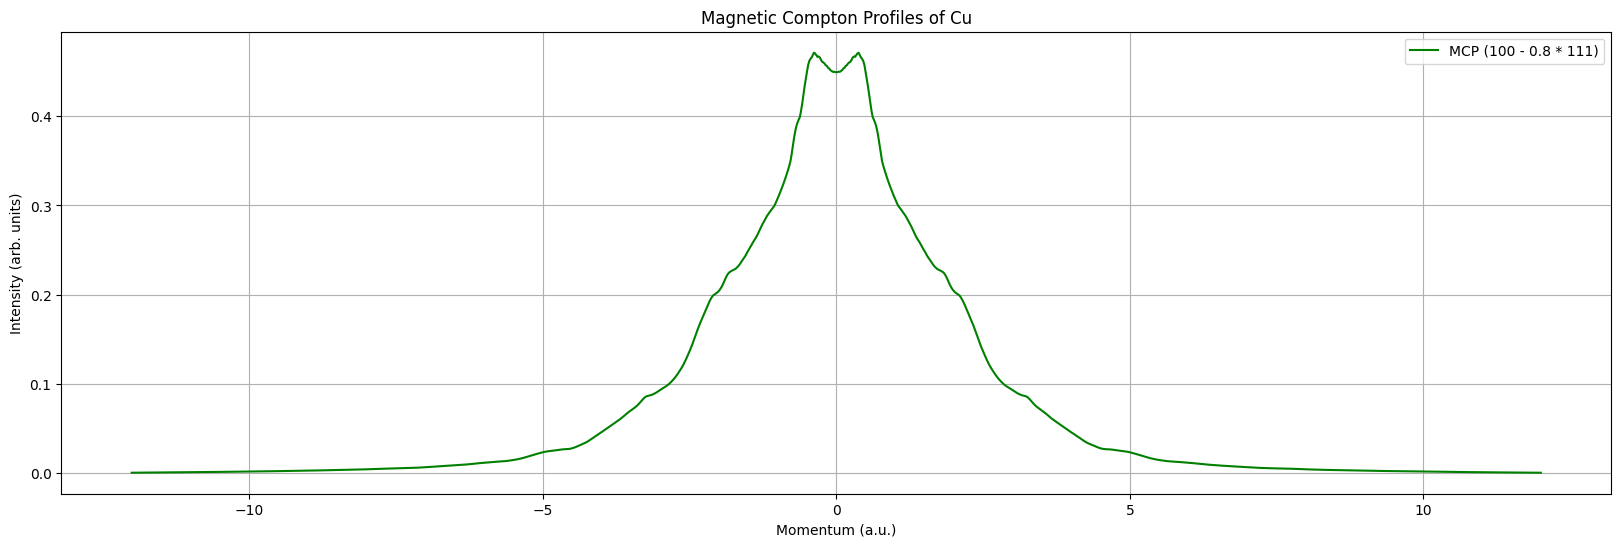

In [11]:
cu100 = np.loadtxt('Cu_Magnetic_Compton/I_EMD1D.OUT_SD_1', comments = '%')
cu111 = np.loadtxt('Cu_Magnetic_Compton/I_EMD1D.OUT_SD_12', comments = '%')

sf = 1e3

x100 = cu100[:,0]
y100_1 = cu100[:,1] * sf
#y100_2 = cu100[:,2] * sf
#mcp100 = y100_1 - 0.8 * y100_2

x111= cu111[:,0]
y111_1 = cu111[:,1] * sf
#y111_2 = cu111[:,2] * sf
#mcp111 = y111_1 - 0.8 * y111_2

mcp = y100_1 - 0.8 * y111_1


plt.figure(figsize=(20,6))
# plt.plot(x100, y100_1, label='Ni 100', color='blue')
# plt.plot(x111, y111_1, label='Ni 111', color='orange')
plt.plot(x100, mcp, label='MCP (100 - 0.8 * 111)', color='green')
plt.xlabel('Momentum (a.u.)')
plt.ylabel('Intensity (arb. units)')
plt.title('Magnetic Compton Profiles of Cu')
plt.legend()
plt.grid()
plt.show()